# Revision Work

Loaded FC data with 200 ROIs  (file last modified 2026-07-04 10:56)

Creating FC anatomical organization visualization...


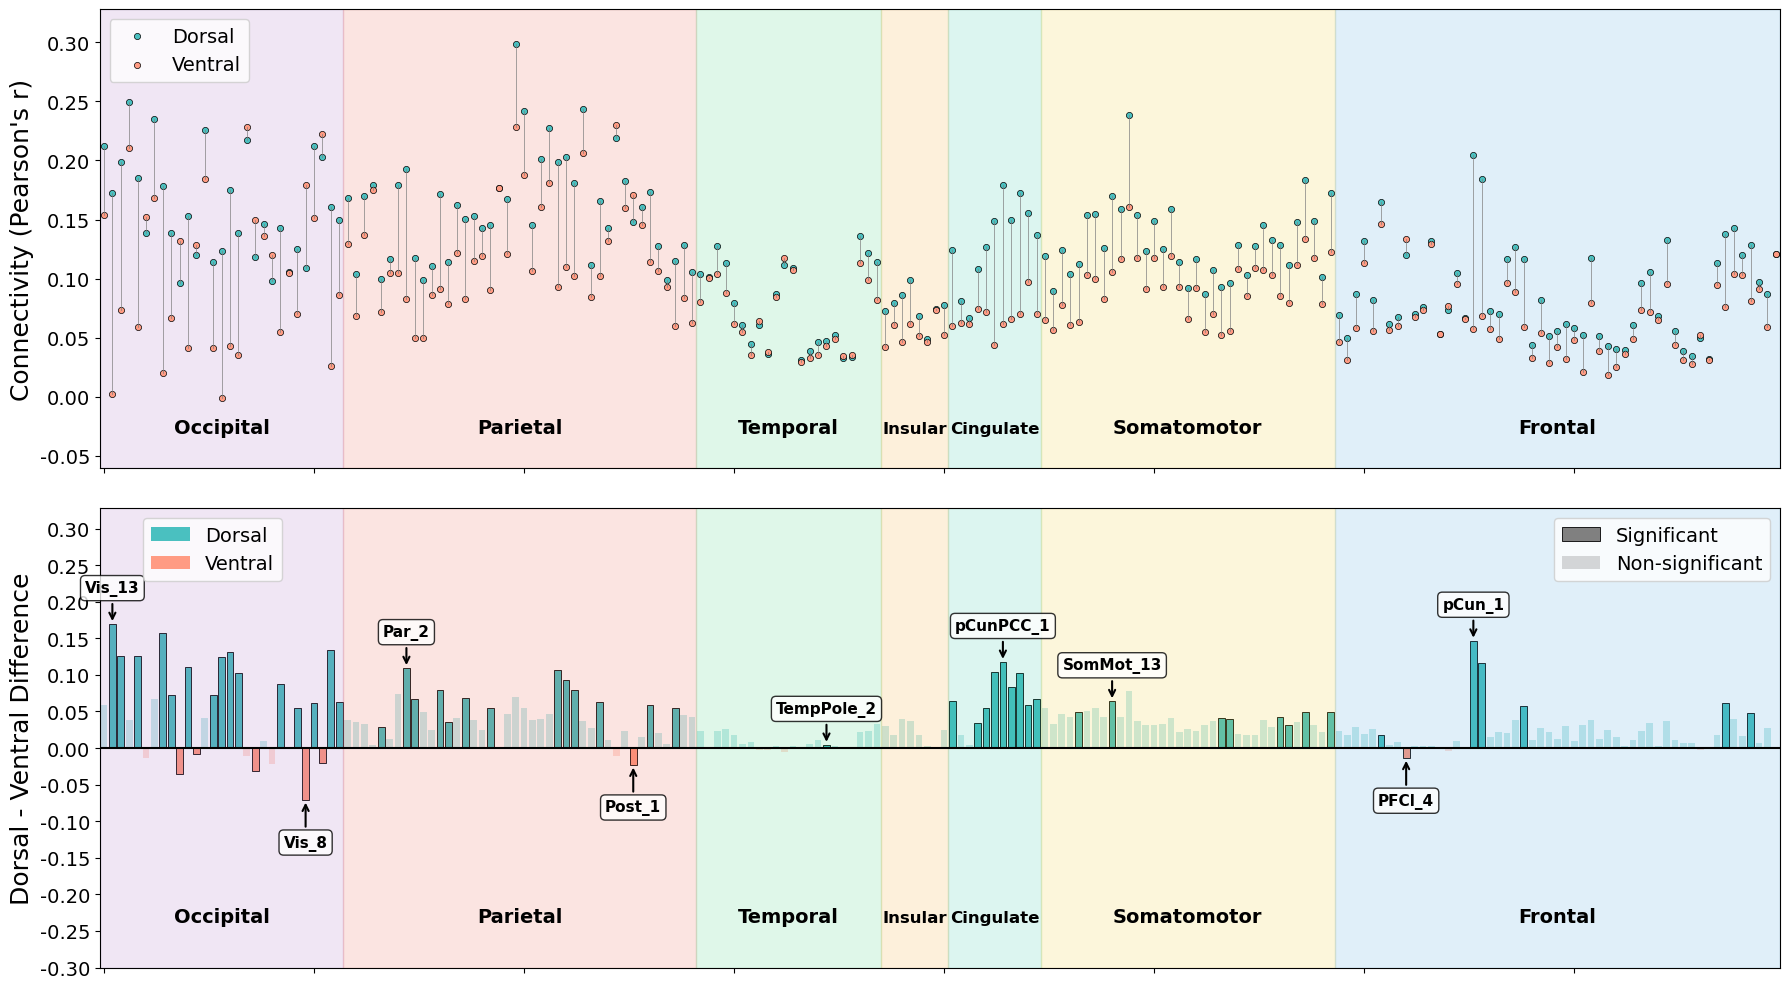

Figure saved to /user_data/csimmon2/git_repos/ptoc/results/connectivity_comparison/fc_anatomical_organization.png

FC significant peak and bottom ROIs by anatomical lobe:

Occipital Lobe:
  Peak (pIPS > LO): Vis_13, Diff = 0.170
  Bottom (LO > pIPS): Vis_8, Diff = -0.071

Parietal Lobe:
  Peak (pIPS > LO): Par_2, Diff = 0.110
  Bottom (LO > pIPS): Post_1, Diff = -0.023

Temporal Lobe:
  Peak (pIPS > LO): TempPole_2, Diff = 0.005
  No significant LO-preferring ROIs in this lobe

Cingulate Lobe:
  Peak (pIPS > LO): pCunPCC_1, Diff = 0.118
  No significant LO-preferring ROIs in this lobe

Somatomotor Lobe:
  Peak (pIPS > LO): SomMot_13, Diff = 0.064
  No significant LO-preferring ROIs in this lobe

Frontal Lobe:
  Peak (pIPS > LO): pCun_1, Diff = 0.147
  Bottom (LO > pIPS): PFCl_4, Diff = -0.014
Loaded PPI data with 200 ROIs  (file last modified 2026-07-04 10:56)

Creating PPI anatomical organization visualization...


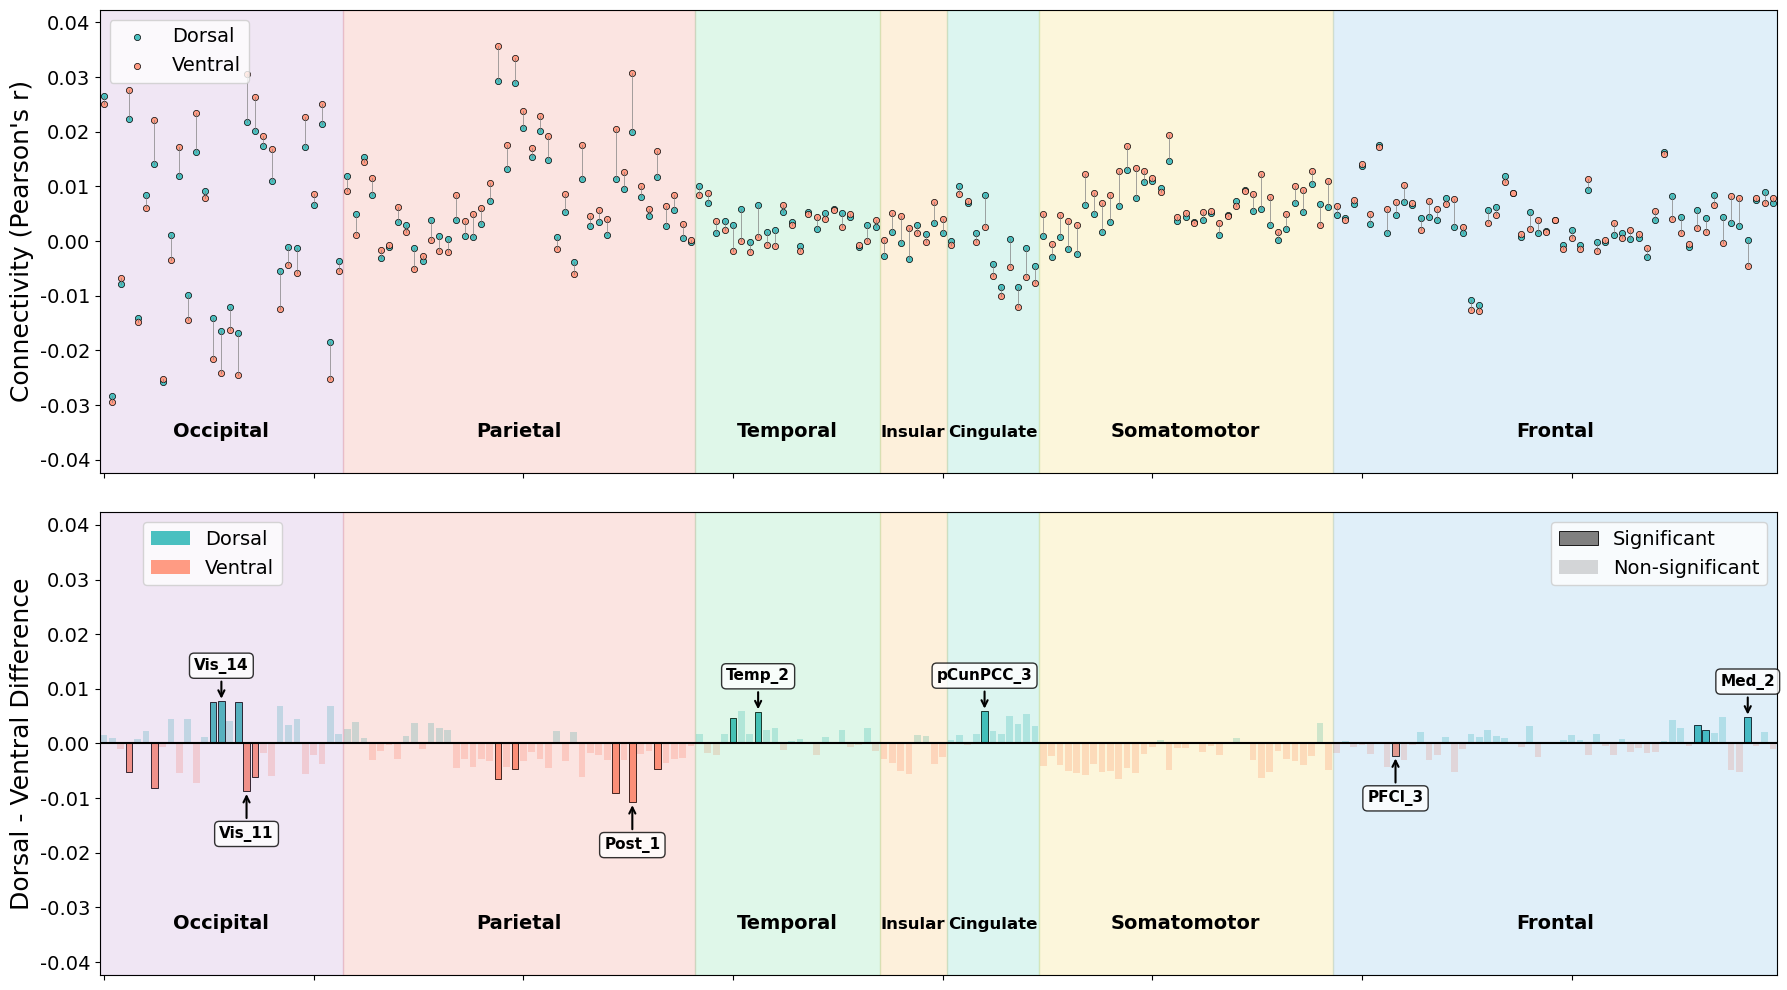

Figure saved to /user_data/csimmon2/git_repos/ptoc/results/connectivity_comparison/ppi_anatomical_organization.png

PPI significant peak and bottom ROIs by anatomical lobe:

Occipital Lobe:
  Peak (pIPS > LO): Vis_14, Diff = 0.008
  Bottom (LO > pIPS): Vis_11, Diff = -0.009

Parietal Lobe:
  No significant pIPS-preferring ROIs in this lobe
  Bottom (LO > pIPS): Post_1, Diff = -0.011

Temporal Lobe:
  Peak (pIPS > LO): Temp_2, Diff = 0.006
  No significant LO-preferring ROIs in this lobe

Cingulate Lobe:
  Peak (pIPS > LO): pCunPCC_3, Diff = 0.006
  No significant LO-preferring ROIs in this lobe

Frontal Lobe:
  Peak (pIPS > LO): Med_2, Diff = 0.005
  Bottom (LO > pIPS): PFCl_3, Diff = -0.002
Loaded PARTIAL_CORRELATION data with 200 ROIs  (file last modified 2026-07-04 10:55)

Creating PARTIAL_CORRELATION anatomical organization visualization...


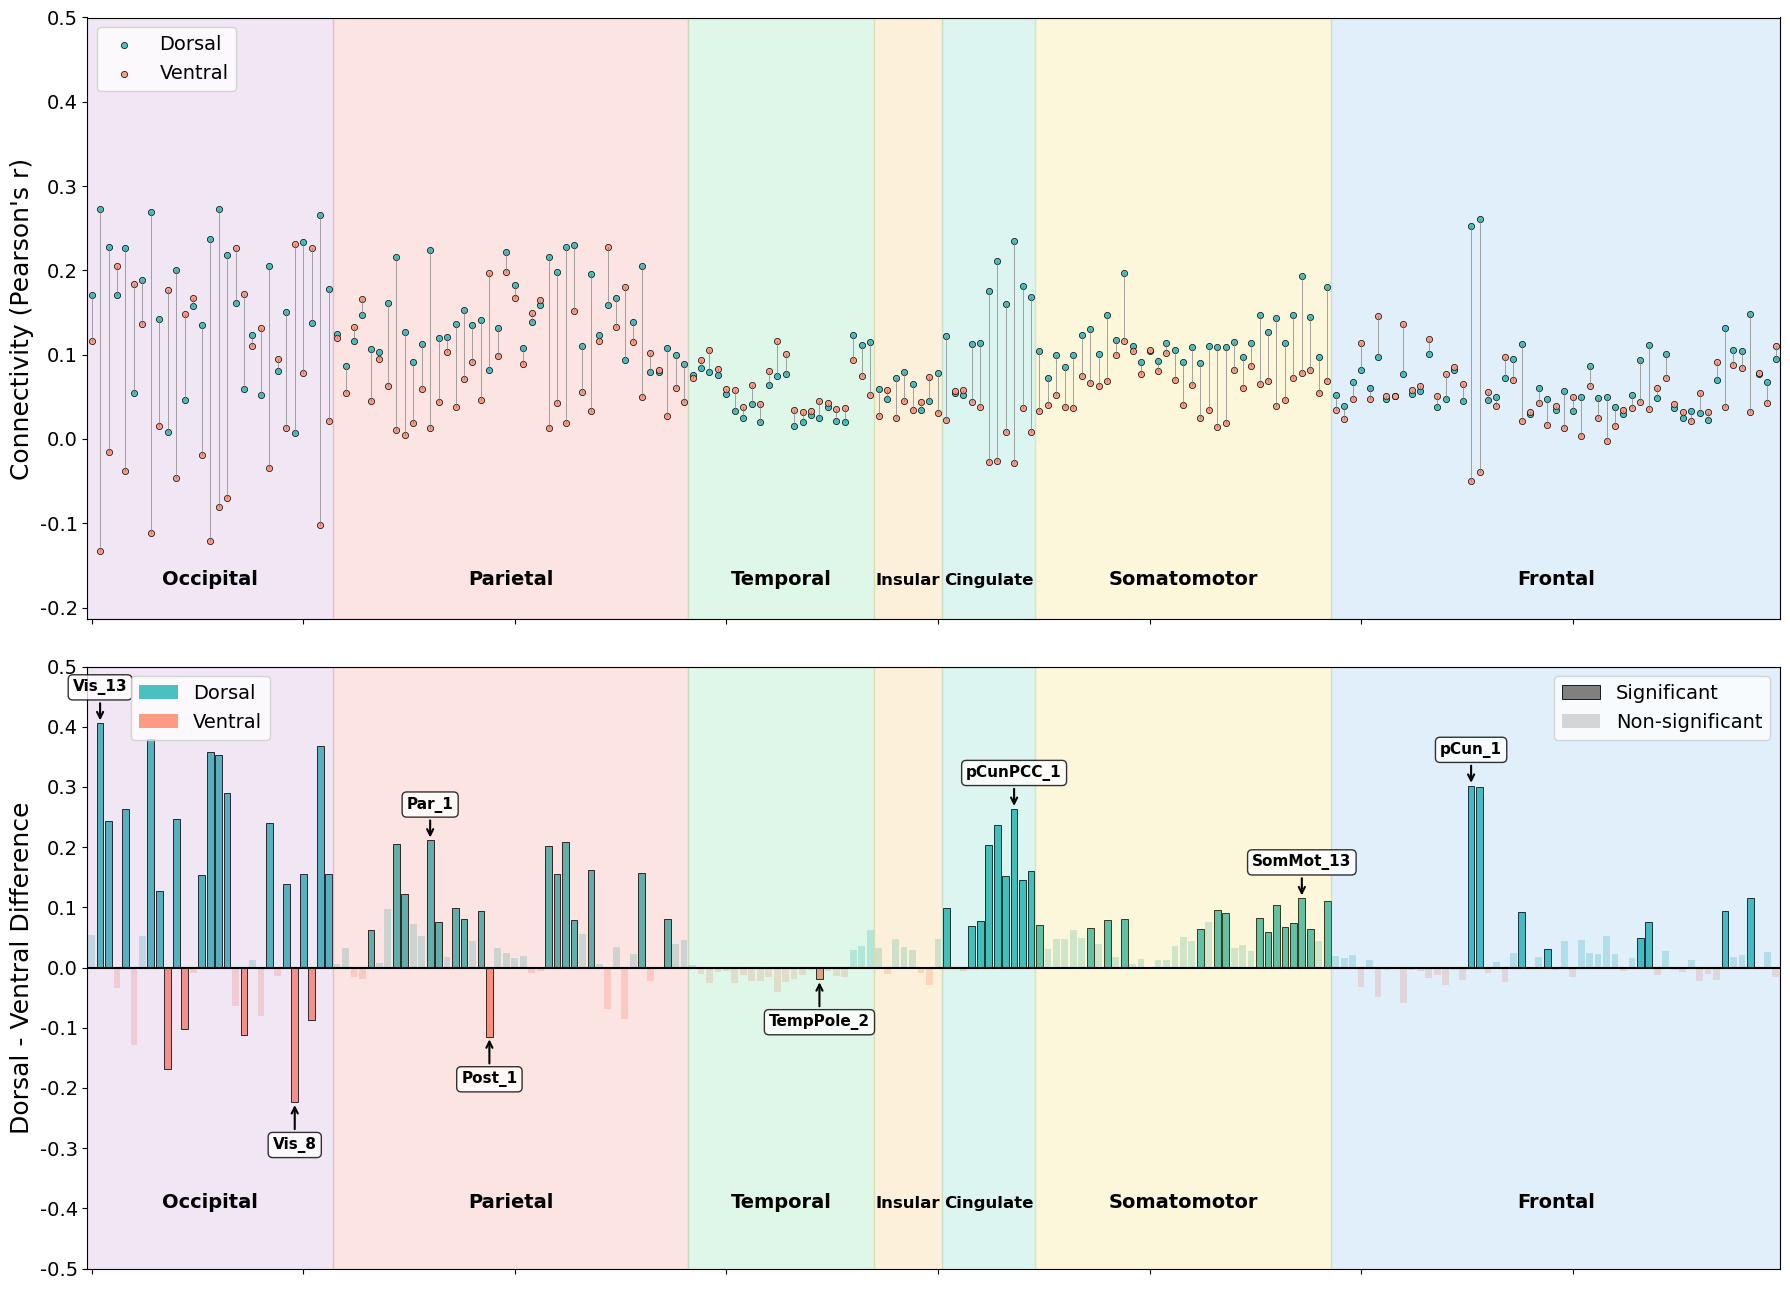

Figure saved to /user_data/csimmon2/git_repos/ptoc/results/connectivity_comparison/partial_correlation_anatomical_organization.png

PARTIAL_CORRELATION significant peak and bottom ROIs by anatomical lobe:

Occipital Lobe:
  Peak (pIPS > LO): Vis_13, Diff = 0.406
  Bottom (LO > pIPS): Vis_8, Diff = -0.224

Parietal Lobe:
  Peak (pIPS > LO): Par_1, Diff = 0.211
  Bottom (LO > pIPS): Post_1, Diff = -0.115

Temporal Lobe:
  No significant pIPS-preferring ROIs in this lobe
  Bottom (LO > pIPS): TempPole_2, Diff = -0.020

Cingulate Lobe:
  Peak (pIPS > LO): pCunPCC_1, Diff = 0.264
  No significant LO-preferring ROIs in this lobe

Somatomotor Lobe:
  Peak (pIPS > LO): SomMot_13, Diff = 0.115
  No significant LO-preferring ROIs in this lobe

Frontal Lobe:
  Peak (pIPS > LO): pCun_1, Diff = 0.302
  No significant LO-preferring ROIs in this lobe


In [22]:
### FINAL FOR REVISION ###
# Standalone cell for FC, PPI, and partial-correlation visualization (Pearson's r)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

# Define paths
results_dir = '/user_data/csimmon2/git_repos/ptoc/results'
output_dir = f'{results_dir}/connectivity_comparison'
os.makedirs(output_dir, exist_ok=True)

# Panel F (difference) y-limits per figure, in Pearson's r units, as (min, max).
# max = None -> match panel E's top (including E's padding).
# Key present -> fixed limits; key absent -> data-driven symmetric (±1.25 x max |difference|).
DIFF_PANEL_YLIM = {'fc': (-0.3, None), 'partial_correlation': (-0.5, 0.5)}

# Figures where panel F reuses panel E's y-axis limits exactly (overrides DIFF_PANEL_YLIM).
MATCH_F_TO_E = {'ppi'}

# Helper functions
def map_to_anatomical_lobe(roi_name):
    """Map ROI names to anatomical lobes"""
    if isinstance(roi_name, bytes):
        roi_name = roi_name.decode('utf-8')
    
    if 'Wang_pIPS' in roi_name:
        return 'Parietal'
    elif 'Wang_LO' in roi_name:
        return 'Temporal'
    
    if 'Vis' in roi_name:
        return 'Occipital'
    elif 'SomMot' in roi_name:
        return 'Somatomotor'
    elif 'DorsAttn' in roi_name:
        if 'Par' in roi_name or 'IPL' in roi_name or 'IPS' in roi_name:
            return 'Parietal'
        elif 'Temp' in roi_name or 'MT' in roi_name:
            return 'Temporal'
        else:
            return 'Parietal'
    elif 'SalVentAttn' in roi_name:
        if 'Ins' in roi_name:
            return 'Insular'
        elif 'Cing' in roi_name or 'ACC' in roi_name:
            return 'Cingulate'
        elif 'Temp' in roi_name:
            return 'Temporal'
        elif 'Par' in roi_name:
            return 'Parietal'
        else:
            return 'Frontal'
    elif 'Limbic' in roi_name:
        if 'Temp' in roi_name:
            return 'Temporal'
        else:
            return 'Frontal'
    elif 'Cont' in roi_name:
        if 'Par' in roi_name or 'IPL' in roi_name or 'IPS' in roi_name:
            return 'Parietal'
        elif 'Temp' in roi_name or 'MT' in roi_name:
            return 'Temporal'
        elif 'Cing' in roi_name:
            return 'Cingulate'
        else:
            return 'Frontal'
    elif 'Default' in roi_name:
        if 'Par' in roi_name:
            return 'Parietal'
        elif 'Temp' in roi_name:
            return 'Temporal'
        elif 'PCC' in roi_name or 'Cing' in roi_name:
            return 'Cingulate'
        else:
            return 'Frontal'
    else:
        return 'Other'

def clean_roi_name(roi_name):
    """Clean up ROI names for better labeling"""
    if isinstance(roi_name, bytes):
        roi_name = roi_name.decode('utf-8')
    
    if 'Wang_' in roi_name:
        return roi_name.replace('Wang_', '')
    
    cleaned = roi_name.replace('7Networks_', '')
    
    parts = cleaned.split('_')
    if len(parts) > 2:
        return parts[-2] + '_' + parts[-1]
    elif len(parts) > 1:
        return parts[-1]
    else:
        return cleaned

def get_hemisphere_and_region(roi_name):
    """Determine hemisphere and base region for organizing pairs"""
    if isinstance(roi_name, bytes):
        roi_name = roi_name.decode('utf-8')
    
    if 'LH' in roi_name:
        hemisphere = 'L'
    elif 'RH' in roi_name:
        hemisphere = 'R'
    else:
        if 'Wang_pIPS' in roi_name or 'Wang_LO' in roi_name:
            hemisphere = 'X'
        else:
            hemisphere = 'X'
    
    cleaned = roi_name.replace('7Networks_', '')
    cleaned = cleaned.replace('LH_', '').replace('RH_', '')
    
    if 'Wang_' in cleaned:
        base_region = cleaned.replace('Wang_', '')
    else:
        base_region = re.sub(r'_\d+$', '', cleaned)
    
    return hemisphere, base_region

def load_data_for_visualization(analysis_type='fc'):
    """Load a converted (Pearson's r) fingerprint CSV; return None if missing.
    Partial correlation lives in its own folder and uses *_clean column names,
    so its path and columns are remapped here to match FC/PPI."""
    if analysis_type == 'partial_correlation':
        csv_path = (f'{results_dir}/partial_correlation_magnitude/'
                    f'bilateral_partial_correlation_connectivity_fingerprint_results_pearsonr.csv')
    else:
        csv_path = f'{output_dir}/bilateral_{analysis_type}_connectivity_fingerprint_results_pearsonr.csv'

    if not os.path.exists(csv_path):
        print(f"Error: {analysis_type.upper()} results file not found at {csv_path}")
        return None

    results_df = pd.read_csv(csv_path)
    # no-op for FC/PPI (columns absent); aligns partial's *_clean names to the plotter's
    results_df = results_df.rename(columns={'pIPS_clean_Connectivity': 'pIPS_Connectivity',
                                            'LO_clean_Connectivity':   'LO_Connectivity'})
    mtime = datetime.fromtimestamp(os.path.getmtime(csv_path))
    print(f"Loaded {analysis_type.upper()} data with {len(results_df)} ROIs  "
          f"(file last modified {mtime:%Y-%m-%d %H:%M})")
    return results_df

def compute_matched_tick_step(*value_arrays, target_ticks=6):
    """Pick one 'nice' y-tick step (1/2/5 x 10^k) shared across panels E and F,
    plus the decimal precision needed to display it. Step is sized to the
    largest-magnitude panel (usually E) so both panels use the same interval."""
    finite = [np.nanmax(np.abs(a)) for a in value_arrays if a is not None and len(a) > 0]
    max_abs = max(finite) if finite else 0.0
    if not np.isfinite(max_abs) or max_abs <= 0:
        return 0.01, 2
    raw = max_abs / target_ticks
    mag = 10 ** np.floor(np.log10(raw))
    step = 10 * mag
    for m in (1, 2, 5, 10):
        if m * mag >= raw:
            step = m * mag
            break
    decimals = max(0, int(-np.floor(np.log10(step))))
    return step, decimals

def visualize_anatomical_organization(results_df, analysis_type='fc'):
    """Create anatomical organization visualization"""
    print(f"\nCreating {analysis_type.upper()} anatomical organization visualization...")
    
    results_df['Anatomical_Lobe'] = results_df['ROI_Name'].apply(map_to_anatomical_lobe)
    results_df['Clean_Name'] = results_df['ROI_Name'].apply(clean_roi_name)
    
    hemisphere_region = results_df['ROI_Name'].apply(get_hemisphere_and_region)
    results_df['Hemisphere'] = [h for h, r in hemisphere_region]
    results_df['Base_Region'] = [r for h, r in hemisphere_region]
    
    lobe_order = [
        'Occipital',
        'Parietal',
        'Temporal',
        'Insular',
        'Cingulate',
        'Somatomotor',
        'Frontal',
        'Other'
    ]
    
    lobe_colors = {
        'Frontal': '#3498db',
        'Somatomotor': '#f1c40f',
        'Parietal': '#e74c3c',
        'Temporal': '#2ecc71',
        'Occipital': '#9b59b6',
        'Insular': '#f39c12',
        'Cingulate': '#1abc9c',
        'Other': '#7f8c8d'
    }
    
    def custom_sort(row):
        lobe_idx = lobe_order.index(row['Anatomical_Lobe']) if row['Anatomical_Lobe'] in lobe_order else 999
        hemi_idx = 0 if row['Hemisphere'] == 'L' else 1 if row['Hemisphere'] == 'R' else 2
        return (lobe_idx, row['Base_Region'], hemi_idx)
    
    results_df['sort_key'] = results_df.apply(custom_sort, axis=1)
    results_df_sorted = results_df.sort_values('sort_key')
    
    sorted_indices = results_df_sorted.index.values
    
    mean_pips_sorted = results_df_sorted['pIPS_Connectivity'].values
    mean_lo_sorted = results_df_sorted['LO_Connectivity'].values
    diff_profile_sorted = results_df_sorted['Difference'].values
    sig_sorted = results_df_sorted['Combined_Significant'].values
    
    # One shared y-tick step for panels E and F (fixes E/F mismatch and PPI's collapsed ticks)
    tick_step, tick_dec = compute_matched_tick_step(mean_pips_sorted, mean_lo_sorted, diff_profile_sorted)
    
    significant_roi_positions = []
    lobe_sections = []
    
    current_lobe = None
    start_idx = 0
    
    for i, idx in enumerate(sorted_indices):
        lobe = results_df_sorted.iloc[i]['Anatomical_Lobe']
        if lobe != current_lobe:
            if current_lobe is not None:
                lobe_sections.append((current_lobe, start_idx, i-1))
            current_lobe = lobe
            start_idx = i
    
    if current_lobe is not None:
        lobe_sections.append((current_lobe, start_idx, len(sorted_indices)-1))
    
    for lobe, start, end in lobe_sections:
        section_indices = sorted_indices[start:end+1]
        section_diff = diff_profile_sorted[start:end+1]
        section_sig = sig_sorted[start:end+1]
        
        sig_positions = np.where(section_sig)[0]
        if len(sig_positions) > 0:
            sig_diffs = section_diff[sig_positions]
            
            if np.max(sig_diffs) > 0:
                max_sig_idx = sig_positions[np.argmax(sig_diffs)]
                significant_roi_positions.append(start + max_sig_idx)
            
            if np.min(sig_diffs) < 0:
                min_sig_idx = sig_positions[np.argmin(sig_diffs)]
                significant_roi_positions.append(start + min_sig_idx)
    
    plt.figure(figsize=(18, 13 if analysis_type == 'partial_correlation' else 10))
    
    ax1 = plt.subplot(2, 1, 1)
    ax1.yaxis.set_major_formatter(FormatStrFormatter(f'%.{tick_dec}f'))
    ax1.yaxis.set_major_locator(MultipleLocator(tick_step))
    x = np.arange(len(mean_pips_sorted))
    
    y_min, y_max = min(min(mean_pips_sorted), min(mean_lo_sorted)), max(max(mean_pips_sorted), max(mean_lo_sorted))
    y_range = y_max - y_min
    
    for lobe, start, end in lobe_sections:
        plt.axvspan(start - 0.5, end + 0.5, alpha=0.15, color=lobe_colors[lobe])
        label_y = y_min - 0.1 * y_range
        if lobe == 'Insular':
            lobe_fontsize = 12
        elif lobe == 'Cingulate':
            lobe_fontsize = 12
        else:
            lobe_fontsize = 14
        plt.text((start + end) / 2, label_y, lobe, ha='center', fontsize=lobe_fontsize, fontweight='bold')
    
    for i in range(len(x)):
        plt.plot([x[i], x[i]], [mean_pips_sorted[i], mean_lo_sorted[i]], color='gray', linestyle='-', linewidth=0.5)
    
    plt.scatter(x, mean_pips_sorted, color='#4ac0c0', s=20, label='Dorsal', edgecolors='black', linewidths=0.5)
    plt.scatter(x, mean_lo_sorted, color='#ff9b83', s=20, label='Ventral', edgecolors='black', linewidths=0.5)
    
    e_ylim = (y_min - 0.2 * y_range, y_max + 0.1 * y_range)
    plt.ylim(*e_ylim)
    
    plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
    plt.tick_params(axis='both', labelsize=14)
    plt.ylabel("Connectivity (Pearson's r)", fontsize=18)
    plt.legend(loc='upper left', fontsize=14)
    plt.xlim(-0.5, len(mean_pips_sorted) - 0.5)
    
    ax2 = plt.subplot(2, 1, 2)
    ax2.yaxis.set_major_formatter(FormatStrFormatter(f'%.{tick_dec}f'))
    ax2.yaxis.set_major_locator(MultipleLocator(tick_step))
    
    base_colors = ['#4ac0c0' if val > 0 else '#ff9b83' for val in diff_profile_sorted]
    bars = plt.bar(x, diff_profile_sorted, color=base_colors)
    
    for i, (bar, is_sig) in enumerate(zip(bars, sig_sorted)):
        if not is_sig:
            bar.set_alpha(0.3)
        else:
            bar.set_edgecolor('black')
            bar.set_linewidth(0.6)
    
    plt.axhline(y=0, color='black', linestyle='-')
    
    sig_legend_elements = [
        Patch(facecolor='gray', edgecolor='black', linewidth=0.6, alpha=1.0, label='Significant'),
        Patch(facecolor='gray', alpha=0.3, label='Non-significant')
    ]
    sig_legend = plt.legend(handles=sig_legend_elements, loc='upper right', fontsize=14)
    
    plt.gca().add_artist(sig_legend)
    
    pref_legend_elements = [
        Patch(facecolor='#4ac0c0', label='Dorsal'),
        Patch(facecolor='#ff9b83', label='Ventral')
    ]
    #plt.legend(handles=pref_legend_elements, loc='upper left', fontsize=14)
    plt.legend(handles=pref_legend_elements, loc='upper left', fontsize=14,
               bbox_to_anchor=(0.02, 1.0))
    
    for lobe, start, end in lobe_sections:
        plt.axvspan(start - 0.5, end + 0.5, alpha=0.15, color=lobe_colors[lobe])
    
    plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
    plt.tick_params(axis='both', labelsize=14)
    
    for position in significant_roi_positions:
        orig_idx = sorted_indices[position]
        roi_name = results_df.loc[orig_idx, 'Clean_Name']
        diff_value = diff_profile_sorted[position]
        
        plt.annotate(f'{roi_name}',
                    xy=(position, diff_value),
                    xytext=(0, 20 if diff_value >= 0 else -25),
                    textcoords='offset points',
                    ha='center',
                    va='bottom' if diff_value >= 0 else 'top',
                    fontsize=11,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
                    arrowprops=dict(arrowstyle='->', lw=1.5))
    
    plt.ylabel('Dorsal - Ventral Difference', fontsize=18)
    plt.xlim(-0.5, len(mean_pips_sorted) - 0.5)
    
    # Panel F y-limits: reuse panel E's (MATCH_F_TO_E), fixed per figure (DIFF_PANEL_YLIM), or data-driven symmetric.
    if analysis_type in MATCH_F_TO_E:
        f_limits = e_ylim              # already includes headroom for lobe labels
        extend_bottom = False
    elif analysis_type in DIFF_PANEL_YLIM:
        lo, hi = DIFF_PANEL_YLIM[analysis_type]
        if hi is None:
            hi = e_ylim[1]             # match panel E's top (incl. E's padding)
        f_limits = (lo, hi)
        extend_bottom = False          # limits are generous; labels sit inside the bottom space
    else:
        d = np.nanmax(np.abs(diff_profile_sorted)) * 1.25
        f_limits = (-d, d)
        extend_bottom = True
    plt.ylim(*f_limits)
    
    current_ylim = plt.ylim()
    y_range_bottom = current_ylim[1] - current_ylim[0]
    
    for lobe, start, end in lobe_sections:
        # below the core when we extend for it; otherwise inside the bottom space
        label_y = current_ylim[0] - 0.1 * y_range_bottom if extend_bottom else current_ylim[0] + 0.1 * y_range_bottom
        if lobe == 'Insular':
            lobe_fontsize = 12
        elif lobe == 'Cingulate':
            lobe_fontsize = 12
        else:
            lobe_fontsize = 14
        plt.text((start + end) / 2, label_y, lobe, ha='center', fontsize=lobe_fontsize, fontweight='bold')
    
    if extend_bottom:
        plt.ylim(current_ylim[0] - 0.15 * y_range_bottom, current_ylim[1])
    
    # Match the upper y-limit of panels E and F (use the taller of the two so nothing clips).
    shared_top = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
    ax1.set_ylim(ax1.get_ylim()[0], shared_top)
    ax2.set_ylim(ax2.get_ylim()[0], shared_top)
    
    plt.tight_layout(h_pad=2.5)
    
    fig_path = f'{output_dir}/{analysis_type}_anatomical_organization.png'
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"Figure saved to {fig_path}")
    
    print(f"\n{analysis_type.upper()} significant peak and bottom ROIs by anatomical lobe:")
    for lobe, start, end in lobe_sections:
        section_indices = sorted_indices[start:end+1]
        section_df = results_df.loc[section_indices]
        
        sig_group = section_df[section_df['Combined_Significant']]
        
        if len(sig_group) > 0:
            print(f"\n{lobe} Lobe:")
            
            pips_group = sig_group[sig_group['Difference'] > 0]
            if len(pips_group) > 0:
                peak_row = pips_group.loc[pips_group['Difference'].idxmax()]
                print(f"  Peak (pIPS > LO): {peak_row['Clean_Name']}, " +
                      f"Diff = {peak_row['Difference']:.3f}")
            else:
                print("  No significant pIPS-preferring ROIs in this lobe")
            
            lo_group = sig_group[sig_group['Difference'] < 0]
            if len(lo_group) > 0:
                bottom_row = lo_group.loc[lo_group['Difference'].idxmin()]
                print(f"  Bottom (LO > pIPS): {bottom_row['Clean_Name']}, " +
                      f"Diff = {bottom_row['Difference']:.3f}")
            else:
                print("  No significant LO-preferring ROIs in this lobe")

# Run visualizations
fc_results = load_data_for_visualization('fc')
if fc_results is not None:
    visualize_anatomical_organization(fc_results, analysis_type='fc')

ppi_results = load_data_for_visualization('ppi')
if ppi_results is not None:
    visualize_anatomical_organization(ppi_results, analysis_type='ppi')

partial_results = load_data_for_visualization('partial_correlation')
if partial_results is not None:
    visualize_anatomical_organization(partial_results, analysis_type='partial_correlation')

Loading FC MNI maps...
  valid subjects: 18
  within (pIPS-LO):   0.914   (manuscript Fig 2D ~0.91)
  between dorsal:     0.830   (~0.83)
  between ventral:    0.789   (~0.79)
saved /user_data/csimmon2/git_repos/ptoc/results/dice_figures/fc_dice_per_subject.csv
Loading partial (residual) MNI maps...
  valid subjects: 18
  within (pIPS-LO):   0.706   (manuscript Fig 4D ~0.706)
  between dorsal:     0.786   (~0.786)
  between ventral:    0.687   (~0.687)
saved /user_data/csimmon2/git_repos/ptoc/results/dice_figures/partial_dice_per_subject.csv


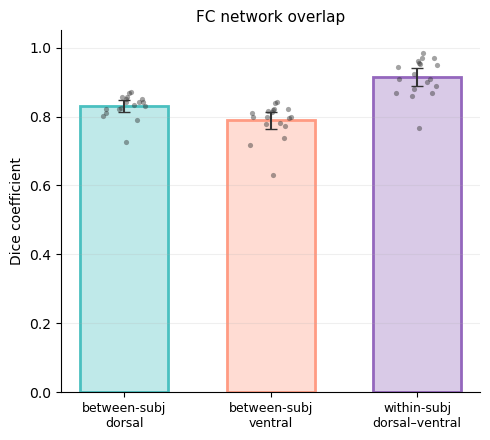

saved /user_data/csimmon2/git_repos/ptoc/results/dice_figures/fig2D_fc_dice.png | between-subj dorsal=0.830  between-subj ventral=0.789  within-subj dorsal–ventral=0.914


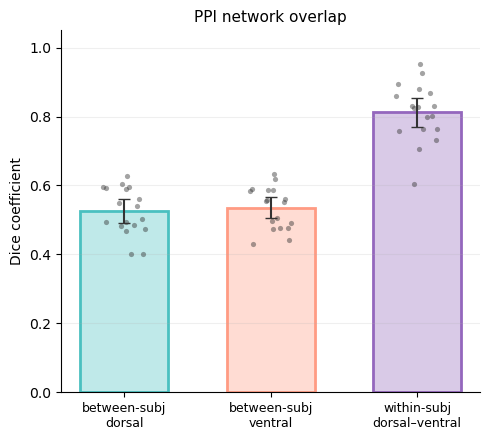

saved /user_data/csimmon2/git_repos/ptoc/results/dice_figures/fig3D_ppi_dice.png | between-subj dorsal=0.525  between-subj ventral=0.535  within-subj dorsal–ventral=0.812


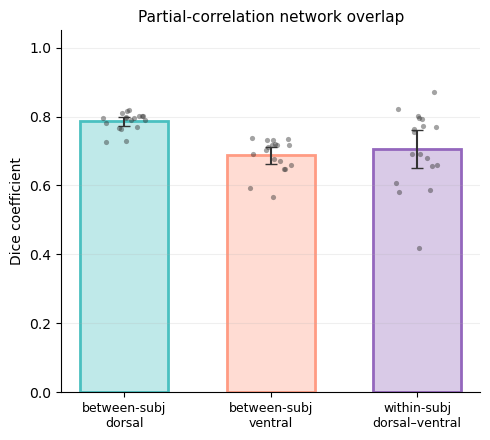

saved /user_data/csimmon2/git_repos/ptoc/results/dice_figures/fig4D_partial_dice.png | between-subj dorsal=0.786  between-subj ventral=0.687  within-subj dorsal–ventral=0.706


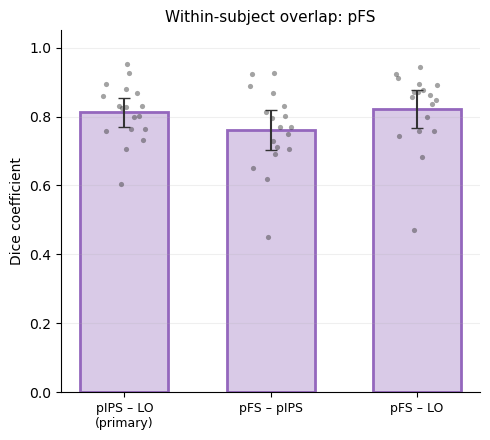

saved /user_data/csimmon2/git_repos/ptoc/results/dice_figures/supp_pFS_dice.png | pIPS – LO (primary)=0.812  pFS – pIPS=0.760  pFS – LO=0.822


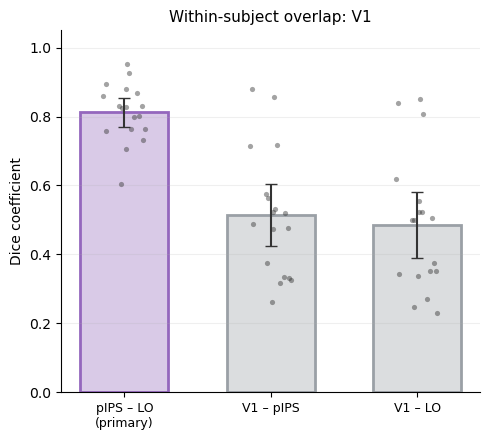

saved /user_data/csimmon2/git_repos/ptoc/results/dice_figures/supp_V1_dice.png | pIPS – LO (primary)=0.812  V1 – pIPS=0.515  V1 – LO=0.485


In [4]:
# %% [Overview]
# All manuscript Dice panels with individual subject dots.
#   Fig 2D  FC          -> needs fc_dice_per_subject.csv       (Cell 2, run once)
#   Fig 3D  PPI         -> acompcor_comparison/dice_per_subject.csv (already saved)
#   Fig 4D  partial     -> needs partial_dice_per_subject.csv  (Cell 3, run once)
#   Supp    pFS control -> acompcor_comparison/dice_per_subject.csv (already saved)
#   Supp    V1  control -> acompcor_comparison/dice_per_subject.csv (already saved)
#
# Order of cells: run Cell 1 (helpers) first. Run Cells 2 and 3 once on the
# cluster to build the FC / partial CSVs. Then Cell 4 plots everything.
# Dice method is identical throughout (avg L+R hemis, binarize > 0, pairwise
# Dice), matching dice_figure_stats.py so numbers stay consistent.


# %% [Cell 1] Setup + plot helpers  (run first)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from scipy import stats

results_dir = '/user_data/csimmon2/git_repos/ptoc/results'
out_dir = f'{results_dir}/dice_figures'
os.makedirs(out_dir, exist_ok=True)

# per-subject Dice CSV sources
ACOMPCOR_CSV = f'{results_dir}/acompcor_comparison/dice_per_subject.csv'   # PPI, pFS, V1
FC_CSV       = f'{out_dir}/fc_dice_per_subject.csv'                        # from Cell 2
PARTIAL_CSV  = f'{out_dir}/partial_dice_per_subject.csv'                   # from Cell 3

TEAL, PINK, PURPLE, GRAY = "#4ac0c0", "#ff9b83", "#9467bd", "#9aa0a6"
FILL_ALPHA = 0.35


def ci95(v):
    v = np.asarray(v, float)
    v = v[~np.isnan(v)]
    m = v.mean()
    lo, hi = stats.t.interval(0.95, len(v) - 1, loc=m, scale=stats.sem(v))
    return m, lo, hi


def bar_with_dots(ax, x, vals, color, width=0.6, seed=0):
    v = np.asarray(vals, float)
    v = v[~np.isnan(v)]
    m, lo, hi = ci95(v)
    ax.bar(x, m, width=width, facecolor=to_rgba(color, FILL_ALPHA),
           edgecolor=color, linewidth=2, zorder=1)
    ax.errorbar(x, m, yerr=[[m - lo], [hi - m]], fmt="none",
                ecolor="#333333", elinewidth=1.5, capsize=4, zorder=3)
    jit = (np.random.RandomState(seed).rand(len(v)) - 0.5) * width * 0.5
    ax.scatter(np.full(len(v), x) + jit, v, s=14, color="#333333",
               alpha=0.45, zorder=2, linewidths=0)


def style_ax(ax, ylim_top=1.05):
    ax.set_ylim(0, ylim_top)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylabel("Dice coefficient")
    ax.grid(axis="y", alpha=0.2)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)


def dice_panel(csv_path, bars, title, out_name, ylim_top=1.05):
    """bars: list of (xlabel, csv_column, color). One panel = outlined bars + dots + 95% CI."""
    if not os.path.exists(csv_path):
        print(f"MISSING csv: {csv_path} -> skipping '{out_name}'")
        return
    df = pd.read_csv(csv_path)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    printed = []
    for i, (lab, col, c) in enumerate(bars):
        if col not in df.columns:
            print(f"  '{out_name}': column '{col}' not in {os.path.basename(csv_path)} -> bar left blank")
            continue
        bar_with_dots(ax, i, df[col].values, c)
        printed.append(f"{lab.replace(chr(10),' ')}={np.nanmean(df[col].values):.3f}")
    ax.set_xticks(range(len(bars)))
    ax.set_xticklabels([l for l, _, _ in bars], fontsize=9)
    ax.set_title(title, fontsize=11)
    style_ax(ax, ylim_top)
    fig.tight_layout()
    path = f'{out_dir}/{out_name}.png'
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved", path, "|", "  ".join(printed))


# %% [Cell 2] Extract FC per-subject Dice -> fc_dice_per_subject.csv  (run ONCE on cluster)
import os
import numpy as np
import pandas as pd
import nibabel as nib

study_dir = "/lab_data/behrmannlab/vlad/ptoc"
results_dir = "/user_data/csimmon2/git_repos/ptoc/results"
out_csv = f"{results_dir}/dice_figures/fc_dice_per_subject.csv"
os.makedirs(os.path.dirname(out_csv), exist_ok=True)

sub_info = pd.read_csv("/user_data/csimmon2/git_repos/ptoc/sub_info.csv")
subs = [s for s in sub_info[sub_info["group"] == "control"]["sub"].tolist()
        if s != "sub-084"]                       # documented exclusion (N=18)

rois = ["pIPS", "LO"]
hemispheres = ["left", "right"]
SUFFIX = "_loc_fc_mni"                            # sub-XXX_pIPS_left_loc_fc_mni.nii.gz


def dice(a, b):
    a, b = (a > 0).astype(int), (b > 0).astype(int)
    tot = a.sum() + b.sum()
    return np.nan if tot == 0 else 2.0 * (a * b).sum() / tot


def load_maps(subs, path_fn):
    data, valid = {}, []
    for sub in subs:
        data[sub], ok = {}, True
        for roi in rois:
            arrs = []
            for hemi in hemispheres:
                f = path_fn(sub, roi, hemi)
                if os.path.exists(f):
                    arrs.append(nib.load(f).get_fdata())
                else:
                    print(f"  missing: {f}"); ok = False
            if len(arrs) == 2:
                data[sub][roi] = (arrs[0] + arrs[1]) / 2
            else:
                ok = False
        if ok:
            valid.append(sub)
    return data, valid


def dice_table(data, valid, dorsal_key, ventral_key):
    within = np.array([dice(data[s][dorsal_key], data[s][ventral_key]) for s in valid])

    def between(key):
        return np.array([np.mean([dice(data[s][key], data[o][key])
                                  for o in valid if o != s]) for s in valid])
    return within, between(dorsal_key), between(ventral_key)


fc_path = lambda sub, roi, hemi: f"{study_dir}/{sub}/ses-01/derivatives/fc_mni/{sub}_{roi}_{hemi}{SUFFIX}.nii.gz"

print("Loading FC MNI maps...")
data, valid = load_maps(subs, fc_path)
print(f"  valid subjects: {len(valid)}")

within, between_dorsal, between_ventral = dice_table(data, valid, "pIPS", "LO")
print(f"  within (pIPS-LO):   {np.nanmean(within):.3f}   (manuscript Fig 2D ~0.91)")
print(f"  between dorsal:     {np.nanmean(between_dorsal):.3f}   (~0.83)")
print(f"  between ventral:    {np.nanmean(between_ventral):.3f}   (~0.79)")

pd.DataFrame({"subject": valid, "within": within,
              "between_dorsal": between_dorsal,
              "between_ventral": between_ventral}).to_csv(out_csv, index=False)
print(f"saved {out_csv}")


# %% [Cell 3] Extract partial per-subject Dice -> partial_dice_per_subject.csv  (run ONCE on cluster)
# Mirrors Cell 2 exactly (avg L+R, binarize > 0, pairwise Dice) but on the
# residualized maps. Per-subject partial maps live under ptoc_residuals (NOT
# study_dir), suffix pIPS_clean / LO_clean  (confirmed in sim_diff_partialreg.ipynb,
# cells 2 & 10). Sanity targets are the manuscript Fig 4D values.
import os
import numpy as np
import pandas as pd
import nibabel as nib

residual_dir = "/user_data/csimmon2/ptoc_residuals"
results_dir = "/user_data/csimmon2/git_repos/ptoc/results"
out_csv = f"{results_dir}/dice_figures/partial_dice_per_subject.csv"
os.makedirs(os.path.dirname(out_csv), exist_ok=True)

sub_info = pd.read_csv("/user_data/csimmon2/git_repos/ptoc/sub_info.csv")
subs = [s for s in sub_info[sub_info["group"] == "control"]["sub"].tolist()
        if s != "sub-084"]

rois = ["pIPS_clean", "LO_clean"]
hemispheres = ["left", "right"]
SUFFIX = "_loc_fc_mni"                            # sub-XXX_pIPS_clean_left_loc_fc_mni.nii.gz


def dice(a, b):
    a, b = (a > 0).astype(int), (b > 0).astype(int)
    tot = a.sum() + b.sum()
    return np.nan if tot == 0 else 2.0 * (a * b).sum() / tot


def load_maps(subs, path_fn):
    data, valid = {}, []
    for sub in subs:
        data[sub], ok = {}, True
        for roi in rois:
            arrs = []
            for hemi in hemispheres:
                f = path_fn(sub, roi, hemi)
                if os.path.exists(f):
                    arrs.append(nib.load(f).get_fdata())
                else:
                    print(f"  missing: {f}"); ok = False
            if len(arrs) == 2:
                data[sub][roi] = (arrs[0] + arrs[1]) / 2
            else:
                ok = False
        if ok:
            valid.append(sub)
    return data, valid


def dice_table(data, valid, dorsal_key, ventral_key):
    within = np.array([dice(data[s][dorsal_key], data[s][ventral_key]) for s in valid])

    def between(key):
        return np.array([np.mean([dice(data[s][key], data[o][key])
                                  for o in valid if o != s]) for s in valid])
    return within, between(dorsal_key), between(ventral_key)


partial_path = lambda sub, roi, hemi: f"{residual_dir}/{sub}/ses-01/derivatives/fc_mni/{sub}_{roi}_{hemi}{SUFFIX}.nii.gz"

print("Loading partial (residual) MNI maps...")
data, valid = load_maps(subs, partial_path)
print(f"  valid subjects: {len(valid)}")

within, between_dorsal, between_ventral = dice_table(data, valid, "pIPS_clean", "LO_clean")
print(f"  within (pIPS-LO):   {np.nanmean(within):.3f}   (manuscript Fig 4D ~0.706)")
print(f"  between dorsal:     {np.nanmean(between_dorsal):.3f}   (~0.786)")
print(f"  between ventral:    {np.nanmean(between_ventral):.3f}   (~0.687)")
# If these are far off 0.71/0.79/0.69, the published 4D likely used the
# FDR-thresholded maps (results/partial_correlation_thresh{,_LO}/) rather than
# raw residuals binarized > 0 -- flag before wiring the panel.

pd.DataFrame({"subject": valid, "within": within,
              "between_dorsal": between_dorsal,
              "between_ventral": between_ventral}).to_csv(out_csv, index=False)
print(f"saved {out_csv}")


# %% [Cell 4] Plot all five Dice panels  (run after Cell 1; needs Cells 2/3 CSVs for 2D/4D)
# Bar order across the three main panels matches the manuscript figures:
# between-subject dorsal, between-subject ventral, within-subject dorsal-ventral.

# Fig 2D  -- FC        (targets: 0.83 / 0.79 / 0.91)
dice_panel(FC_CSV,
    [("between-subj\ndorsal",              "between_dorsal",  TEAL),
     ("between-subj\nventral",             "between_ventral", PINK),
     ("within-subj\ndorsal\u2013ventral",  "within",          PURPLE)],
    "FC network overlap", "fig2D_fc_dice")

# Fig 3D  -- PPI       (targets: 0.525 / 0.535 / 0.81)
dice_panel(ACOMPCOR_CSV,
    [("between-subj\ndorsal",              "between_dorsal",  TEAL),
     ("between-subj\nventral",             "between_ventral", PINK),
     ("within-subj\ndorsal\u2013ventral",  "pIPS_LO",         PURPLE)],
    "PPI network overlap", "fig3D_ppi_dice")

# Fig 4D  -- partial correlation  (targets: 0.786 / 0.687 / 0.706)
dice_panel(PARTIAL_CSV,
    [("between-subj\ndorsal",              "between_dorsal",  TEAL),
     ("between-subj\nventral",             "between_ventral", PINK),
     ("within-subj\ndorsal\u2013ventral",  "within",          PURPLE)],
    "Partial-correlation network overlap", "fig4D_partial_dice")

# Supplementary -- pFS control (within-subject overlap of pFS with each seed)
dice_panel(ACOMPCOR_CSV,
    [("pIPS \u2013 LO\n(primary)", "pIPS_LO",  PURPLE),
     ("pFS \u2013 pIPS",           "PFS_pIPS", PURPLE),
     ("pFS \u2013 LO",             "PFS_LO",   PURPLE)],
    "Within-subject overlap: pFS", "supp_pFS_dice")

# Supplementary -- V1 control
dice_panel(ACOMPCOR_CSV,
    [("pIPS \u2013 LO\n(primary)", "pIPS_LO", PURPLE),
     ("V1 \u2013 pIPS",            "V1_pIPS", GRAY),
     ("V1 \u2013 LO",              "V1_LO",   GRAY)],
    "Within-subject overlap: V1", "supp_V1_dice")